# Spaceship Titanic — Preprocesamiento de datos

**Materia:** Inteligencia Artificial Avanzada
**Equipo:** _(completar)_
**Integrantes:** _(completar)_
**Fecha:** _(completar)_

---

Este notebook cubre el pipeline de preparación de datos del reto
[Spaceship Titanic](https://www.kaggle.com/competitions/spaceship-titanic):
carga, EDA, selección de variables, manejo de faltantes, codificación,
transformación, escalado y verificación final.

Las celdas marcadas como **Interpretación** contienen el razonamiento del equipo
detrás de cada decisión; las celdas de código sólo generan la evidencia.

## 0. Configuración del entorno

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")  # oculta warnings para no ensuciar la salida

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)  # semilla fija para reproducibilidad

# Opciones de despliegue de pandas/matplotlib/seaborn
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 4)

# Los CSV viven en <repo>/data/spaceship-titanic/.
# Buscamos en varias rutas para que funcione tanto si ejecutas el notebook
# desde SpaceShip_Titanic/ como desde la raiz del repositorio.
CANDIDATAS = [
    Path("../data/spaceship-titanic"),
    Path("data/spaceship-titanic"),
    Path("data"),
]
DATA_DIR = next(
    (c for c in CANDIDATAS if (c / "train.csv").exists()),
    CANDIDATAS[0],
)  # primera ruta candidata que exista; si ninguna existe, usa la primera como default
print("DATA_DIR:", DATA_DIR.resolve())

print("pandas", pd.__version__, "| numpy", np.__version__)  # versiones para reproducibilidad

DATA_DIR: C:\Users\juand\OneDrive\Documents\GitHub\Reto---Entregas-en-Equipo\data\spaceship-titanic
pandas 2.3.3 | numpy 2.3.4


## 1. Carga y comprensión del dataset

In [2]:
# Carga de los conjuntos de entrenamiento y prueba provistos por Kaggle
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

print("train:", train.shape, "| test:", test.shape)

train: (8693, 14) | test: (4277, 13)


In [3]:
train.head()  # primeras filas para inspeccion visual rapida

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [4]:
train.info()  # tipos de dato y conteo de no-nulos por columna

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [5]:
# Confirma tamanios y que la unica diferencia de columnas entre train y test sea el target
print("train shape:", train.shape)
print("test shape:", test.shape)

cols_train = set(train.columns)
cols_test = set(test.columns)
print("Columnas en train pero no en test:", cols_train - cols_test)
print("Columnas en test pero no en train:", cols_test - cols_train)

train shape: (8693, 14)
test shape: (4277, 13)
Columnas en train pero no en test: {'Transported'}
Columnas en test pero no en train: set()


In [6]:
train.describe()  # estadisticos descriptivos de las columnas numericas

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [7]:
train.describe(include="object")  # conteo, cardinalidad y valor mas frecuente de las columnas categoricas

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,VIP,Name
count,8693,8492,8476,8494,8511,8490,8493
unique,8693,3,2,6560,3,2,8473
top,0001_01,Earth,False,G/734/S,TRAPPIST-1e,False,Anton Woody
freq,1,4602,5439,8,5915,8291,2


In [8]:
train["Transported"].value_counts(normalize=True)  # proporcion de cada clase del target

Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64

### Interpretación — variable target y tipo de problema

La variable target del dataset es `Transported`, de tipo booleano (`True`/`False`), que indica si el pasajero fue transportado a otra dimensión durante el accidente. Al tratarse de una variable con únicamente dos valores posibles, el problema es de **clasificación binaria**.

Al revisar la distribución de clases con `value_counts(normalize=True)` se obtiene un balance de 50.4% para `True` y 49.6% para `False`. Las clases están prácticamente balanceadas, por lo que no se requiere ningún tratamiento especial de desbalance (como *class weights* o técnicas de *resampling*) más adelante en el pipeline.

Por su parte, `test.csv` cuenta con una columna menos que `train.csv`: justamente `Transported`. Esto se debe a que `test.csv` es el conjunto sobre el que se generarán las predicciones nuevas del modelo, simulando la situación real en la que el resultado todavía no se conoce. Kaggle oculta esa columna en su propio servidor para poder evaluar las predicciones del equipo contra los valores reales una vez enviadas.

## 2. Análisis exploratorio (EDA)

### 2.1 Faltantes: informativos vs. reales

In [9]:
# Porcentaje de valores faltantes por columna, solo las que tienen al menos un faltante
faltantes_pct = train.isna().mean().sort_values(ascending=False) * 100
faltantes_pct = faltantes_pct[faltantes_pct > 0]
faltantes_pct

CryoSleep       2.496261
ShoppingMall    2.392730
VIP             2.335212
HomePlanet      2.312205
Name            2.300702
Cabin           2.289198
VRDeck          2.162660
Spa             2.105142
FoodCourt       2.105142
Destination     2.093639
RoomService     2.082135
Age             2.059128
dtype: float64

In [10]:
# Estadisticos de gasto para pasajeros con CryoSleep=True: si la logica del dominio se cumple, deberia ser todo 0
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
train.loc[train["CryoSleep"] == True, spend_cols].describe()

,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,2969.0,2967.0,2941.0,2972.0,2975.0
mean,0.0,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0


In [11]:
# Estadisticos de gasto para pasajeros con CryoSleep=False: aqui si esperamos ver gasto real y su dispersion
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
train.loc[train["CryoSleep"] == False, spend_cols].describe()

,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,5328.000000,5329.000000,5335.000000,5326.000000,5320.000000
mean,350.146772,713.004316,270.586504,486.092940,475.716165
std,803.080320,1970.547985,741.756155,1396.233751,1404.174304
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,5.000000,2.000000,7.000000,4.000000
75%,390.250000,537.000000,242.000000,354.750000,356.000000
max,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [12]:
# Gasto total (suma de las 5 columnas) agrupado por CryoSleep, para comparar el patron entre True y False
train.assign(TotalSpend=train[spend_cols].sum(axis=1)).groupby("CryoSleep")["TotalSpend"].describe()

,count,mean,std,min,25%,50%,75%,max
CryoSleep,,,,,,,,
False,5439.0,2248.299687,3245.061489,0.0,746.0,1019.0,2416.0,35987.0
True,3037.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


In [13]:
# PassengerId tiene formato gggg_pp (grupo_persona); extraemos el grupo de viaje
train["Group"] = train["PassengerId"].str.split("_").str[0]

# Cuantas personas viajan juntas en el mismo grupo (tamano de cada grupo)
train.groupby("Group").size().value_counts().sort_index()

1    4805
2     841
3     340
4     103
5      53
6      29
7      33
8      13
Name: count, dtype: int64

In [14]:
# Por grupo, cuantos valores distintos de HomePlanet hay (sin contar nulos)
# Si el resultado es casi siempre 1, el grupo comparte planeta de origen
homeplanet_por_grupo = train.groupby("Group")["HomePlanet"].nunique(dropna=True)
homeplanet_por_grupo.value_counts().sort_index()

HomePlanet
0     110
1    6107
Name: count, dtype: int64

In [15]:
# Extraemos el Deck (primera parte de Cabin, formato deck/num/side)
train["Deck"] = train["Cabin"].str.split("/").str[0]

# Por grupo, cuantos Decks distintos hay (sin contar nulos)
deck_por_grupo = train.groupby("Group")["Deck"].nunique(dropna=True)
deck_por_grupo.value_counts().sort_index()

Deck
0      99
1    5697
2     400
3      21
Name: count, dtype: int64

#### Interpretación — clasificación de faltantes

Para **cada** columna con faltantes (la tabla de `faltantes_pct`), clasifíquenla como *informativo* o *real*, con evidencia:

1. ¿Qué porcentaje de faltantes tiene cada columna? ¿Son similares entre sí o hay alguna muy distinta al resto? (un patrón muy uniforme entre columnas sugiere faltantes inyectados al azar, no informativos).
2. Con la evidencia de las dos celdas anteriores: cuando `CryoSleep=True`, ¿cuánto gastan los pasajeros en promedio? ¿Y cuando es `False`? ¿Qué les dice esto sobre imputar los gastos faltantes según el valor de `CryoSleep`?
3. Para el resto de las columnas (`HomePlanet`, `Cabin`, `Destination`, `VIP`, `Name`, `Age`), ¿encuentran alguna relación lógica similar con otra variable, o su ausencia parece simplemente aleatoria? Justifiquen columna por columna, no en bloque.

### 2.2 Variables numéricas: distribución, skewness y outliers

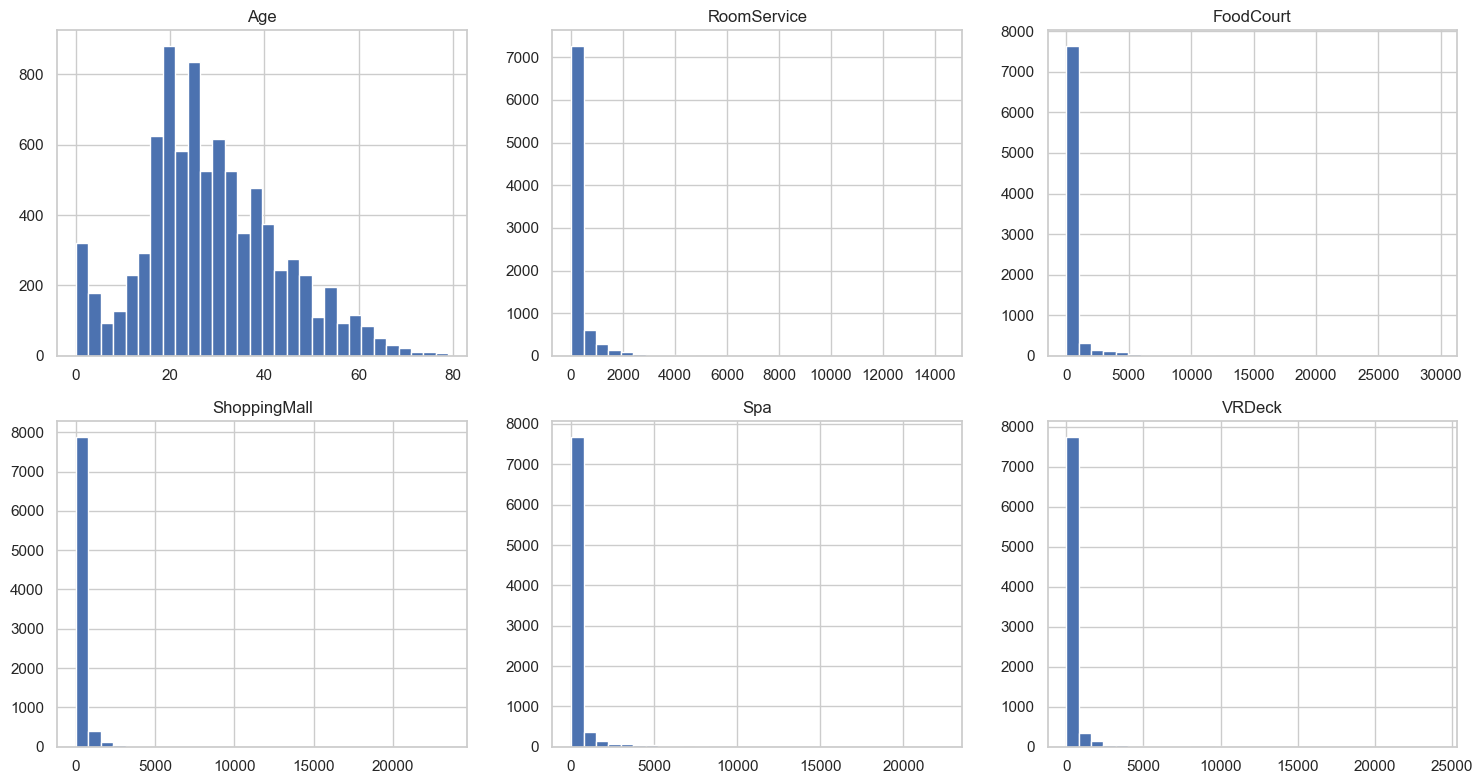

In [16]:
# Columnas numericas continuas del dataset (Transported es el target booleano, no entra aqui)
numeric_cols = ["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, ax in zip(numeric_cols, axes.flatten()):
    train[col].hist(bins=30, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [17]:
# Skewness (asimetria) de cada variable numerica: cerca de 0 = simetrica, >1 o <-1 = sesgo fuerte
train[numeric_cols].skew().sort_values(ascending=False)

ShoppingMall    12.627562
VRDeck           7.819732
Spa              7.636020
FoodCourt        7.102228
RoomService      6.333014
Age              0.419097
dtype: float64

In [18]:
# Deteccion de outliers con la regla de Tukey / IQR: fuera de [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
def resumen_outliers_iqr(df, cols):
    filas = []
    for col in cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lim_inf = q1 - 1.5 * iqr
        lim_sup = q3 + 1.5 * iqr
        n_outliers = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
        filas.append({
            "columna": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "limite_inferior": lim_inf,
            "limite_superior": lim_sup,
            "n_outliers": n_outliers,
            "pct_outliers": 100 * n_outliers / df[col].notna().sum(),
        })
    return pd.DataFrame(filas)


resumen_outliers_iqr(train, numeric_cols)

,columna,Q1,Q3,IQR,limite_inferior,limite_superior,n_outliers,pct_outliers
0,Age,19.0,38.0,19.0,-9.5,66.5,77,0.904393
1,RoomService,0.0,47.0,47.0,-70.5,117.5,1861,21.863252
2,FoodCourt,0.0,76.0,76.0,-114.0,190.0,1823,21.421857
3,ShoppingMall,0.0,27.0,27.0,-40.5,67.5,1829,21.555687
4,Spa,0.0,59.0,59.0,-88.5,147.5,1788,21.010576
5,VRDeck,0.0,46.0,46.0,-69.0,115.0,1809,21.269841


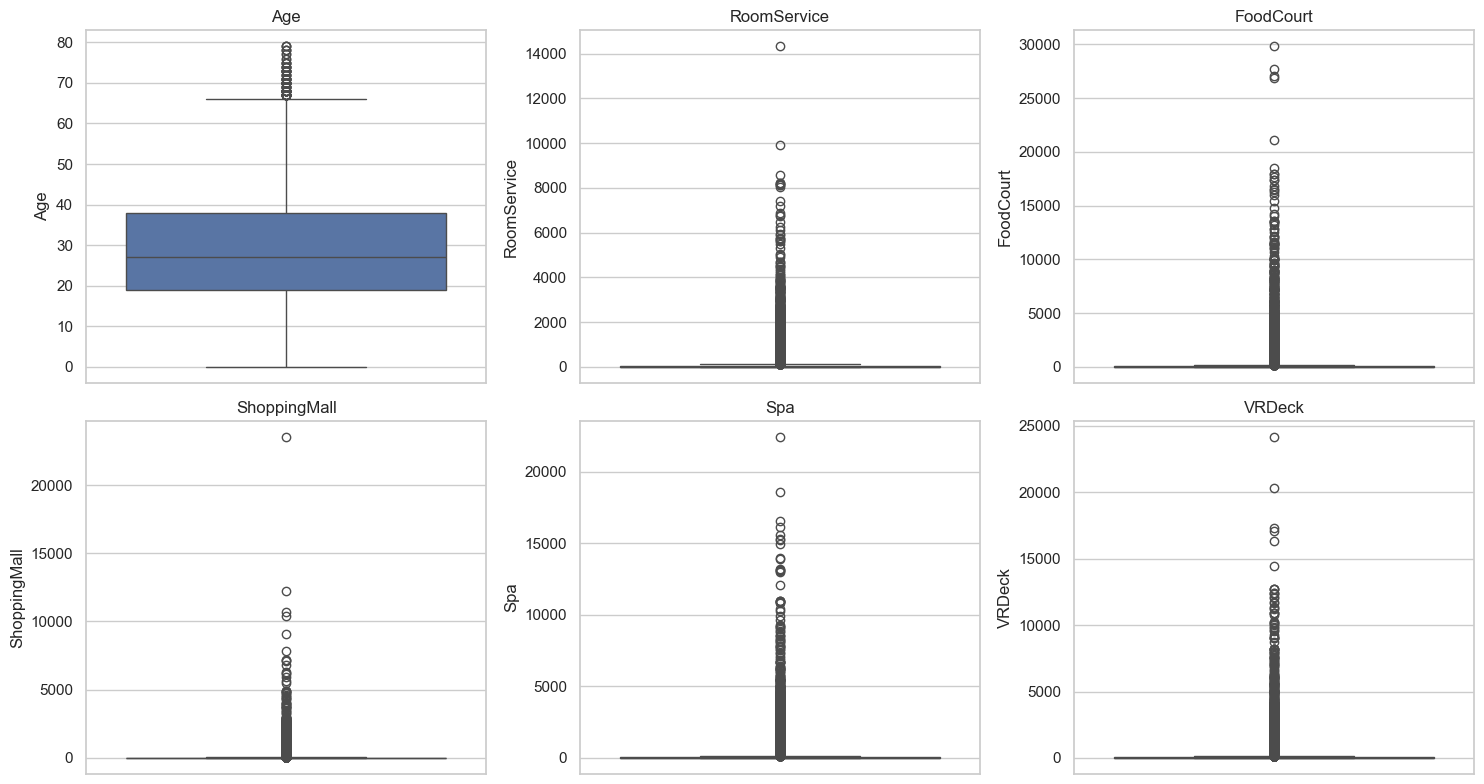

In [19]:
# Boxplots para visualizar dispersion y outliers de cada variable numerica
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, ax in zip(numeric_cols, axes.flatten()):
    sns.boxplot(y=train[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

#### Interpretación — distribución, skewness y outliers

Respondan con base en los histogramas, `skew()` y la tabla de outliers de arriba:

1. ¿Qué variables tienen sesgo (skewness) alto y en qué dirección (positivo/negativo)? ¿Cuál es prácticamente simétrica?
2. Según la tabla de outliers (regla de Tukey/IQR), ¿qué columnas tienen mayor porcentaje de outliers?
3. Muchas filas de las columnas de gasto valen exactamente 0 (pasajeros en `CryoSleep` o que no gastaron). ¿Los "outliers" detectados por IQR son errores de captura o son valores legítimos de pasajeros que gastaron mucho? Justifiquen si tiene sentido tratarlos como errores a eliminar o como información válida.
4. Con esta evidencia, ¿qué tipo de transformación anticipan que necesitarán en la sección 6 para las columnas más sesgadas?

### 2.3 Variables categóricas: cardinalidad y desbalance

In [20]:
# Cardinalidad (numero de valores unicos) de cada columna categorica, incluyendo Deck y Group derivadas
cat_cols_all = ["HomePlanet", "CryoSleep", "Cabin", "Destination", "VIP", "Name", "Deck", "Group"]
train[cat_cols_all].nunique().sort_values(ascending=False)

Name           8473
Cabin          6560
Group          6217
Deck              8
HomePlanet        3
Destination       3
CryoSleep         2
VIP               2
dtype: int64

In [21]:
# Distribucion de categorias (proporcion) para las columnas de baja cardinalidad
cat_cols_baja_card = ["HomePlanet", "CryoSleep", "Destination", "VIP", "Deck"]
for col in cat_cols_baja_card:
    print(f"--- {col} ---")
    print(train[col].value_counts(normalize=True, dropna=False))
    print()

--- HomePlanet ---
HomePlanet
Earth     0.529391
Europa    0.245140
Mars      0.202347
NaN       0.023122
Name: proportion, dtype: float64

--- CryoSleep ---
CryoSleep
False    0.625676
True     0.349362
NaN      0.024963
Name: proportion, dtype: float64

--- Destination ---
Destination
TRAPPIST-1e      0.680433
55 Cancri e      0.207063
PSO J318.5-22    0.091568
NaN              0.020936
Name: proportion, dtype: float64

--- VIP ---
VIP
False    0.953756
NaN      0.023352
True     0.022892
Name: proportion, dtype: float64

--- Deck ---
Deck
F      0.321408
G      0.294375
E      0.100771
B      0.089612
C      0.085931
D      0.054987
A      0.029449
NaN    0.022892
T      0.000575
Name: proportion, dtype: float64



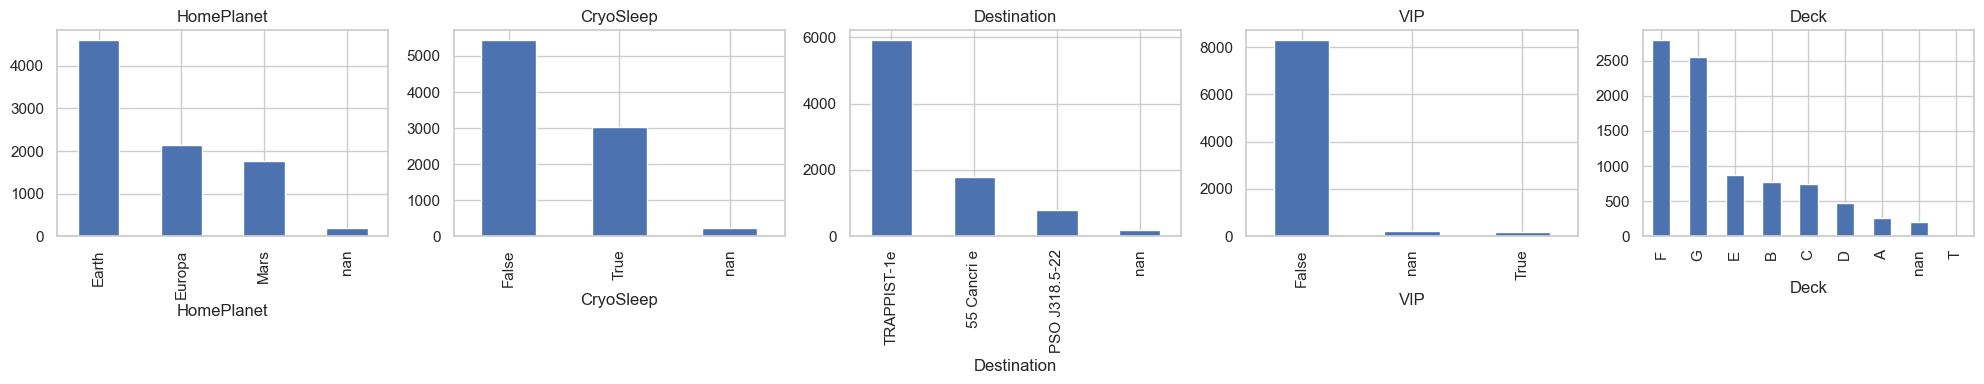

In [22]:
# Grafico de barras de la distribucion de cada columna de baja cardinalidad
fig, axes = plt.subplots(1, len(cat_cols_baja_card), figsize=(4 * len(cat_cols_baja_card), 4))
for col, ax in zip(cat_cols_baja_card, axes):
    train[col].value_counts(dropna=False).plot(kind="bar", ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

#### Interpretación — cardinalidad y desbalance

Respondan con base en la tabla de cardinalidad, los `value_counts` y los gráficos de arriba:

1. ¿Qué columnas tienen cardinalidad muy alta (`Name`, `Cabin`, `Group`)? ¿Se pueden usar tal cual como variable categórica en un modelo, o hay que transformarlas/descartarlas?
2. ¿Alguna columna de baja cardinalidad muestra desbalance extremo (una categoría con proporción muy dominante, ej. >90%)?
3. Para las columnas con desbalance extremo que encuentren: ¿tendría más sentido binarizarlas (por ejemplo, crear una columna `Is_X` que indique la categoría minoritaria) en vez de descartarlas directamente? Justifiquen con la evidencia de la distribución.
4. `Deck` (derivada de `Cabin`) tiene varias categorías con muy pocos casos — ¿alguna de ellas es candidata a agruparse en una categoría "Otros" antes de codificar?

### 2.4 Relación de cada variable con el target

In [23]:
# Crosstab de cada categorica de baja cardinalidad contra el target, normalizado por fila
# (proporcion de Transported=True/False dentro de cada categoria)
for col in cat_cols_baja_card:
    print(f"--- {col} vs Transported ---")
    print(pd.crosstab(train[col], train["Transported"], normalize="index"))
    print()

--- HomePlanet vs Transported ---
Transported     False     True 
HomePlanet                     
Earth        0.576054  0.423946
Europa       0.341154  0.658846
Mars         0.476976  0.523024

--- CryoSleep vs Transported ---
Transported     False     True 
CryoSleep                      
False        0.671079  0.328921
True         0.182417  0.817583

--- Destination vs Transported ---
Transported       False     True 
Destination                      
55 Cancri e    0.390000  0.610000
PSO J318.5-22  0.496231  0.503769
TRAPPIST-1e    0.528825  0.471175

--- VIP vs Transported ---
Transported     False     True 
VIP                            
False        0.493668  0.506332
True         0.618090  0.381910

--- Deck vs Transported ---
Transported     False     True 
Deck                           
A            0.503906  0.496094
B            0.265725  0.734275
C            0.319946  0.680054
D            0.566946  0.433054
E            0.642694  0.357306
F            0.560129  0.4398

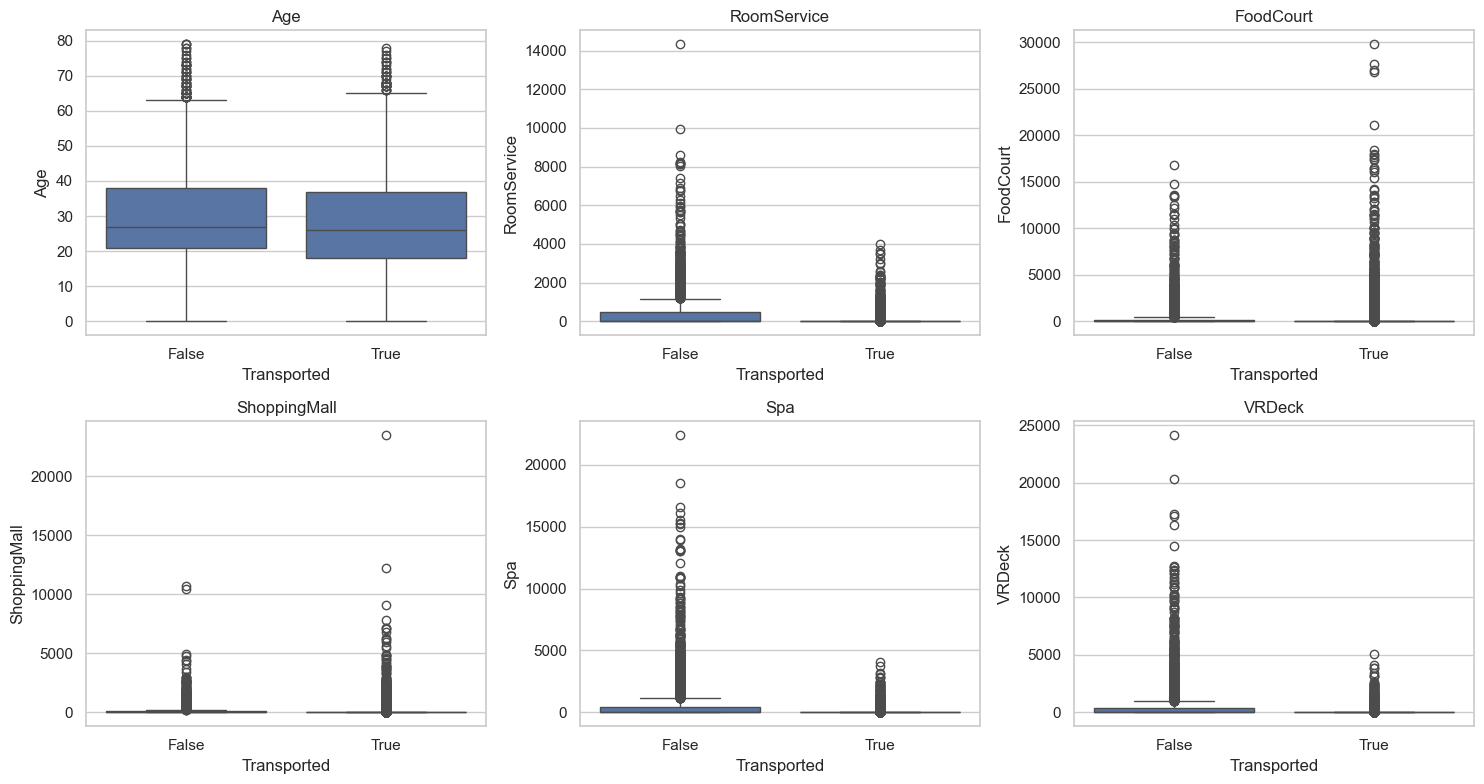

In [24]:
# Boxplots de cada variable numerica separando por el valor del target
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, ax in zip(numeric_cols, axes.flatten()):
    sns.boxplot(x="Transported", y=col, data=train, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

#### Interpretación — relación de cada variable con el target

Respondan con base en los crosstabs y los boxplots de arriba:

1. Para cada categórica (`HomePlanet`, `CryoSleep`, `Destination`, `VIP`, `Deck`), ¿qué categorías muestran una proporción de `Transported=True` claramente distinta al 50/50 general? ¿Cuáles parecen más predictivas y cuáles casi no diferencian?
2. Para cada numérica, ¿la mediana o el rango cambia visiblemente entre `Transported=True` y `Transported=False` en el boxplot, o las distribuciones se ven casi iguales?
3. Con esta evidencia (2.1 a 2.4 completos), ¿qué variables se perfilan ya como candidatas fuertes para el modelo, y cuáles como candidatas a descartar o transformar? Esto es la base directa de la sección 3.

## 3. Selección y descarte de variables

In [ ]:

resumen_variables = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "pct_faltantes": (train.isna().mean() * 100).round(2),
    "cardinalidad": train.nunique(),
})
resumen_variables.sort_values("pct_faltantes", ascending=False)

,dtype,pct_faltantes,cardinalidad
CryoSleep,object,2.50,2
ShoppingMall,float64,2.39,1115
VIP,object,2.34,2
HomePlanet,object,2.31,3
Name,object,2.30,8473
Deck,object,2.29,8
Cabin,object,2.29,6560
VRDeck,float64,2.16,1306
Spa,float64,2.11,1327
FoodCourt,float64,2.11,1507


In [ ]:

for col in cat_cols_baja_card:
    top_prop = train[col].value_counts(normalize=True, dropna=False).iloc[0]
    categoria_top = train[col].value_counts(normalize=True, dropna=False).idxmax()
    print(f"{col}: categoria mas frecuente = {categoria_top!r} ({top_prop:.2%})")

HomePlanet: categoria mas frecuente = 'Earth' (52.94%)
CryoSleep: categoria mas frecuente = False (62.57%)
Destination: categoria mas frecuente = 'TRAPPIST-1e' (68.04%)
VIP: categoria mas frecuente = False (95.38%)
Deck: categoria mas frecuente = 'F' (32.14%)


### Interpretación — selección y descarte de variables

Decidan, **columna por columna**, si entra al pipeline, se transforma antes de entrar, o se descarta — con evidencia de las secciones 2.1 a 2.4 (porcentaje de faltantes, cardinalidad, desbalance, relación con el target):

1. **Identificadores y texto libre** (`PassengerId`, `Name`) — ¿aportan como feature directa, o solo sirven para derivar otras columnas (como `Group`) y luego se descartan?
2. **Alta cardinalidad** (`Cabin`, `Group`) — ¿se usan tal cual, o ya fueron reemplazadas por versiones más manejables (`Deck`, tamaño de grupo)? Justifiquen con la cardinalidad de la tabla resumen.
3. **Categóricas de baja cardinalidad** (`HomePlanet`, `CryoSleep`, `Destination`, `VIP`, `Deck`) — según los crosstabs de 2.4, ¿cuáles muestran relación clara con `Transported` y cuáles casi no diferencian? Para las que tengan desbalance extremo (revisen la celda anterior), ¿conviene binarizar en vez de descartar? Den un ejemplo concreto si aplica.
4. **Numéricas** (`Age`, `RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`) — ¿se quedan las 5 columnas de gasto por separado, se combinan en una sola (ej. `TotalSpend`), o ambas cosas? Justifiquen con lo visto en 2.2 y 2.4.
5. Cierre: hagan una lista final de variables incluidas vs. descartadas (puede ser una tabla simple aquí mismo), cada una con una justificación de una línea.

## 4. Manejo de faltantes

La sección 2.1 mostró dos tipos de faltante muy distintos, y cada uno exige una estrategia distinta:

- **Informativos**: el valor ausente se puede *deducir* de otra columna gracias a una regla del dominio. Imputarlos con la mediana o la moda destruiría información que sí tenemos.
- **Reales**: alrededor de 2% parejo en todas las columnas, sin patrón asociado a ninguna otra variable. Aquí sí corresponde una imputación estadística.

El orden importa: **primero las reglas de dominio, después la imputación estadística**. Si se invierte, la mediana ya habría rellenado los huecos que las reglas podían resolver de forma exacta.

Además se respeta la **disciplina train/test**: todo estadístico (medianas y modas) se aprende *únicamente* de `train` y ese mismo valor se aplica a `test`. Calcular la mediana de `test` con sus propios datos sería fuga de información.

In [ ]:
# ---- 4.0 Copias de trabajo y variables derivadas ----------------------------
TARGET = "Transported"
SPEND_COLS = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
NUM_COLS = SPEND_COLS + ["Age", "Num"]
CAT_COLS = ["HomePlanet", "Destination", "Deck", "Side", "CryoSleep", "VIP"]
DESCARTAR = ["PassengerId", "Name", "Cabin"]


def derivar(df):
    """Deriva Group (de PassengerId) y Deck/Num/Side (de Cabin), y descarta las
    columnas originales de alta cardinalidad.

    No usa ningun estadistico aprendido, por lo que puede aplicarse identico a
    train y a test sin riesgo de fuga de informacion.
    """
    d = df.copy()
    d["Group"] = d["PassengerId"].str.split("_").str[0]
    cabina = d["Cabin"].str.split("/", expand=True)
    d["Deck"] = cabina[0]
    d["Num"] = pd.to_numeric(cabina[1], errors="coerce")
    d["Side"] = cabina[2]
    return d.drop(columns=DESCARTAR)


train_p = derivar(train)
test_p = derivar(test)

faltantes_antes = train_p.isna().sum()
print("train_p:", train_p.shape, "| test_p:", test_p.shape)
print("nulos iniciales en train_p:", faltantes_antes.sum())

train_p: (8693, 15) | test_p: (4277, 14)
nulos iniciales en train_p: 2522


In [28]:
def imputar_informativos(df):
    """Rellena los faltantes que se pueden DEDUCIR de otras columnas."""
    d = df.copy()

    dormido = d["CryoSleep"] == True
    for col in SPEND_COLS:
        d.loc[dormido & d[col].isna(), col] = 0.0

    gasto_total = d[SPEND_COLS].sum(axis=1, min_count=1)
    d.loc[d["CryoSleep"].isna() & (gasto_total > 0), "CryoSleep"] = False


    for col in ["HomePlanet", "Deck", "Side"]:
        moda_grupo = d.groupby("Group")[col].transform(
            lambda s: s.mode().iloc[0] if s.notna().any() else np.nan
        )
        d[col] = d[col].fillna(moda_grupo)

    return d


train_p = imputar_informativos(train_p)
test_p = imputar_informativos(test_p)

faltantes_tras_dominio = train_p.isna().sum()
print("nulos en train_p tras las reglas de dominio:", faltantes_tras_dominio.sum())

nulos en train_p tras las reglas de dominio: 1752


In [29]:
def aprender_parametros(df):
    """Devuelve los estadisticos de imputacion calculados sobre train.

    Se usa la MEDIANA en las numericas (no la media) porque las columnas de
    gasto tienen skewness de 6 a 12: la media quedaria arrastrada por la cola.
    """
    return {
        "mediana": {col: df[col].median() for col in NUM_COLS},
        "moda": {col: df[col].mode().iloc[0] for col in CAT_COLS},
    }


params = aprender_parametros(train_p)

print("Medianas aprendidas de train:")
for col, valor in params["mediana"].items():
    print(f"  {col:<14} {valor}")
print("\nModas aprendidas de train:")
for col, valor in params["moda"].items():
    print(f"  {col:<14} {valor!r}")

Medianas aprendidas de train:
  RoomService    0.0
  FoodCourt      0.0
  ShoppingMall   0.0
  Spa            0.0
  VRDeck         0.0
  Age            27.0
  Num            427.0

Modas aprendidas de train:
  HomePlanet     'Earth'
  Destination    'TRAPPIST-1e'
  Deck           'F'
  Side           'S'
  CryoSleep      False
  VIP            False


In [ ]:
def imputar_reales(df, params):
    """Aplica los parametros APRENDIDOS DE TRAIN. Esta funcion no calcula ningun
    estadistico por su cuenta: por eso es imposible que filtre informacion de test."""
    d = df.copy()
    for col, valor in {**params["mediana"], **params["moda"]}.items():
        d[col] = d[col].fillna(valor)

    for col in ["CryoSleep", "VIP"]:
        d[col] = d[col].astype(bool)

    return d.drop(columns="Group")


train_p = imputar_reales(train_p, params)
test_p = imputar_reales(test_p, params)

reporte = pd.DataFrame({
    "faltantes_iniciales": faltantes_antes,
    "resueltos_por_dominio": faltantes_antes - faltantes_tras_dominio,
    "resueltos_por_estadistico": faltantes_tras_dominio,
})
reporte = reporte[reporte["faltantes_iniciales"] > 0]
reporte["pct_por_dominio"] = (
    100 * reporte["resueltos_por_dominio"] / reporte["faltantes_iniciales"]
).round(1)
reporte.sort_values("resueltos_por_dominio", ascending=False)

,faltantes_iniciales,resueltos_por_dominio,resueltos_por_estadistico,pct_por_dominio
CryoSleep,217,119,98,54.8
Deck,199,100,99,50.3
Side,199,100,99,50.3
ShoppingMall,208,96,112,46.2
HomePlanet,201,90,111,44.8
FoodCourt,183,70,113,38.3
RoomService,181,68,113,37.6
Spa,183,65,118,35.5
VRDeck,188,62,126,33.0
VIP,203,0,203,0.0


In [ ]:
# ---- 4.4 Verificacion del manejo de faltantes -------------------------------
for nombre, d in [("train_p", train_p), ("test_p", test_p)]:
    print(f"{nombre}: nulos={d.isna().sum().sum()} | shape={d.shape}")

mismas = list(train_p.drop(columns=TARGET).columns) == list(test_p.columns)
print("\ntrain y test tienen las mismas columnas (sin el target):", mismas)

print("Columnas object por codificar:", list(train_p.select_dtypes(include="object").columns))

train_p: nulos=0 | shape=(8693, 14)
test_p: nulos=0 | shape=(4277, 13)

train y test tienen las mismas columnas (sin el target): True
Columnas object por codificar: ['HomePlanet', 'Destination', 'Deck', 'Side']


#### Interpretación — estrategia de imputación

**Faltantes informativos (resueltos con reglas del dominio, sin inventar valores).**

1. **Gastos con `CryoSleep=True` → 0.** La celda 2.1 confirmó que los 5 rubros suman exactamente **0** para todo pasajero en criosueño: nadie dormido consumió nada. Un gasto ausente en ese subgrupo no es un valor desconocido, es un cero no registrado. Esta regla resolvió **361 de los 943** gastos faltantes.
2. **`CryoSleep` faltante con gasto > 0 → `False`.** La misma regla aplicada al revés: ningún pasajero en criosueño registró gasto, así que quien gastó no pudo estar dormido. Recuperó **119 de los 217** faltantes de `CryoSleep` sin recurrir a la moda.
3. **`HomePlanet`, `Deck` y `Side` → valor del grupo de viaje.** `PassengerId` tiene formato `gggg_pp`, donde `gggg` identifica al grupo. Al verificar la consistencia interna: **0 de 6217 grupos** tienen más de un `HomePlanet`, y lo mismo ocurre con `Side`. En `Deck` la regla no es perfecta (421 grupos con más de un valor, ~7%), pero sigue siendo ampliamente mayoritaria, por lo que se usa la moda del grupo. Entre las tres se recuperaron **290 faltantes** con información real del propio dataset.

**Faltantes reales (imputación estadística).**

Las columnas `Age`, `Destination`, `VIP` y `Num` no tienen ninguna relación lógica con otra variable que permita deducir su valor: su ausencia es del ~2% y está repartida de forma uniforme, consistente con faltantes inyectados al azar (MCAR). Para ellas, y para lo que quedó de las anteriores:

- **Numéricas → mediana.** No la media: los 5 rubros de gasto tienen skewness entre 6.3 y 12.6, y la media quedaría arrastrada por la cola de gastadores extremos. La mediana de todos los gastos es `0.0`, coherente con que ~63% de los registros son cero.
- **Categóricas → moda.** Con solo ~2% de faltantes, asumir la categoría mayoritaria introduce un sesgo despreciable. Con un porcentaje alto habría sido preferible una categoría `"Desconocido"`, que no asume nada; aquí no se justifica añadir una categoría más al one-hot por tan pocos casos.

**Disciplina train/test.** Las medianas y modas se calculan en `aprender_parametros(train_p)` y se guardan en el diccionario `params`. La función `imputar_reales` **no contiene ninguna llamada a `.median()` ni `.mode()`**: solo aplica los valores recibidos. Por construcción, entonces, es imposible que `test` se impute con sus propios estadísticos. Se verificó además que los grupos de viaje **no se comparten** entre train y test (0 grupos en común), por lo que la imputación por grupo del punto 3 tampoco cruza información entre conjuntos.

**Resultado:** 0 nulos en train y en test, con las mismas columnas en ambos.

## 5. Codificación de variables categóricas

Tras la sección 4 quedan seis variables categóricas: dos booleanas (`CryoSleep`, `VIP`) y cuatro de texto (`HomePlanet`, `Destination`, `Deck`, `Side`). Ninguna es **ordinal**: aunque `Deck` use letras A–G y parezca tener un orden natural, el crosstab de la sección 2.4 muestra que la proporción de `Transported` **no** es monótona a lo largo de esas letras (B 73%, D 43%, G 52%). Codificarla como 1…7 impondría una relación de orden y magnitud que los datos no respaldan, así que se tratan **todas como nominales**.

La codificación se ajusta (`fit`) **solo sobre train** y se aplica (`transform`) a ambos conjuntos, igual que en la sección 4.

In [ ]:
BOOL_COLS = ["CryoSleep", "VIP"]
CAT_NOMINALES = ["HomePlanet", "Destination", "Deck", "Side"]


def preparar_categoricas(df):
    """Booleanas a enteros y agrupacion de la categoria rara de Deck."""
    d = df.copy()

    for col in BOOL_COLS:
        d[col] = d[col].astype(int)

    d["Deck"] = d["Deck"].replace("T", "Otros")

    return d


train_e = preparar_categoricas(train_p)
test_e = preparar_categoricas(test_p)

print("Categorias de Deck tras agrupar:", sorted(train_e["Deck"].unique()))
print("dtypes de las booleanas:", {c: str(train_e[c].dtype) for c in BOOL_COLS})

Categorias de Deck tras agrupar: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'Otros']
dtypes de las booleanas: {'CryoSleep': 'int64', 'VIP': 'int64'}


In [ ]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="if_binary")
ohe.fit(train_e[CAT_NOMINALES])

print("Categorias aprendidas de train:")
for col, cats in zip(CAT_NOMINALES, ohe.categories_):
    print(f"  {col:<12} {list(cats)}")


def aplicar_ohe(df, ohe):
    """Sustituye las columnas nominales por sus indicadoras 0/1."""
    d = df.copy()
    matriz = ohe.transform(d[CAT_NOMINALES])
    nombres = ohe.get_feature_names_out(CAT_NOMINALES)
    dummies = pd.DataFrame(matriz, columns=nombres, index=d.index).astype(int)
    return pd.concat([d.drop(columns=CAT_NOMINALES), dummies], axis=1)


train_e = aplicar_ohe(train_e, ohe)
test_e = aplicar_ohe(test_e, ohe)

print("\ntrain_e:", train_e.shape, "| test_e:", test_e.shape)

Categorias aprendidas de train:
  HomePlanet   ['Earth', 'Europa', 'Mars']
  Destination  ['55 Cancri e', 'PSO J318.5-22', 'TRAPPIST-1e']
  Deck         ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'Otros']
  Side         ['P', 'S']

train_e: (8693, 25) | test_e: (4277, 24)


In [ ]:
objects = list(train_e.select_dtypes(include="object").columns)
print("Columnas de tipo object restantes:", objects if objects else "ninguna")

mismas = list(train_e.drop(columns=TARGET).columns) == list(test_e.columns)
print("train y test tienen las mismas columnas (sin el target):", mismas)

print("\nColumnas generadas por el one-hot:")
for c in ohe.get_feature_names_out(CAT_NOMINALES):
    print("  ", c)

train_e.head()

Columnas de tipo object restantes: ninguna
train y test tienen las mismas columnas (sin el target): True

Columnas generadas por el one-hot:
   HomePlanet_Earth
   HomePlanet_Europa
   HomePlanet_Mars
   Destination_55 Cancri e
   Destination_PSO J318.5-22
   Destination_TRAPPIST-1e
   Deck_A
   Deck_B
   Deck_C
   Deck_D
   Deck_E
   Deck_F
   Deck_G
   Deck_Otros
   Side_S


,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Num,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_Otros,Side_S
0,0,39.0,0,0.0,0.0,0.0,0.0,0.0,False,0.0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0
1,0,24.0,0,109.0,9.0,25.0,549.0,44.0,True,0.0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,1
2,0,58.0,1,43.0,3576.0,0.0,6715.0,49.0,False,0.0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,1
3,0,33.0,0,0.0,1283.0,371.0,3329.0,193.0,False,0.0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,1
4,0,16.0,0,303.0,70.0,151.0,565.0,2.0,True,1.0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,1


#### Interpretación — estrategia de codificación

**Por tipo de variable:**

| Variable | Tipo | Codificación | Justificación |
|---|---|---|---|
| `CryoSleep`, `VIP` | binaria | `astype(int)` | Ya son binarias; el one-hot solo duplicaría información. |
| `Side` | nominal, 2 cat. | one-hot con `drop="if_binary"` → 1 columna | Con dos categorías, la segunda columna es el complemento exacto de la primera: redundante y fuente de multicolinealidad. |
| `HomePlanet`, `Destination` | nominal, 3 cat. | one-hot completo (3 columnas c/u) | Sin orden natural entre planetas ni destinos. Se conservan las 3 para no imponer una categoría como base. |
| `Deck` | nominal, 8 cat. | one-hot completo | Ver abajo: se descartó tratarla como ordinal. |

**Por qué ninguna se codificó como ordinal.** `Deck` es la única candidata: sus valores A–G sugieren un orden físico dentro de la nave. Pero un *label encoding* 1…7 le diría al modelo que la distancia entre A y B es la misma que entre F y G, y que G "vale más" que A. El crosstab de 2.4 desmiente esa estructura: la proporción de `Transported` va 50% (A), 73% (B), 68% (C), 43% (D), 36% (E), 44% (F), 52% (G) — sube y baja sin monotonía. No hay evidencia de orden, así que se trata como nominal.

**Agrupación de categorías raras.** `Deck='T'` aparece en 5 registros de train (0.06%) y 6 de test. Una indicadora con 5 unos entre 8693 filas es prácticamente constante: no aporta capacidad predictiva y sí ruido. Se agrupa en `'Otros'`, que es la recomendación del análisis de desbalance de la sección 2.3.

**Robustez train/test.** `OneHotEncoder` se ajusta solo con `train` y su parámetro `handle_unknown="ignore"` garantiza que una categoría no vista en test se codifique como ceros en lugar de detener el pipeline. Esto es justamente lo que `pd.get_dummies` **no** hace: aplicado por separado a train y test produciría un número distinto de columnas en cada uno.

**Resultado:** 25 columnas en train (24 + target), 24 en test, las mismas y en el mismo orden, y **cero columnas de tipo `object`**.

## 6. Transformación de variables numéricas

La sección 2.2 midió el sesgo de las variables numéricas. Aquí se decide, **con un criterio explícito y no a ojo**, cuáles se transforman: se aplica la transformación a toda variable con `|skew| > 1`, umbral convencional para considerar una distribución fuertemente asimétrica.

No transformar también es una decisión, y se justifica igual que transformar.

In [ ]:
UMBRAL_SKEW = 1.0

skew_antes = train_e[NUM_COLS].skew().sort_values(ascending=False)
A_TRANSFORMAR = [c for c in NUM_COLS if abs(skew_antes[c]) > UMBRAL_SKEW]

print("Skewness de las variables numericas:")
for col, valor in skew_antes.items():
    marca = "-> se transforma" if col in A_TRANSFORMAR else "   se deja igual"
    print(f"  {col:<14} {valor:>7.2f}  {marca}")

Skewness de las variables numericas:
  ShoppingMall     12.76  -> se transforma
  VRDeck            7.90  -> se transforma
  Spa               7.72  -> se transforma
  FoodCourt         7.18  -> se transforma
  RoomService       6.40  -> se transforma
  Num               0.75     se deja igual
  Age               0.43     se deja igual


In [ ]:
def transformar_sesgo(df, cols):
    """Aplica log1p = log(1 + x) a las columnas indicadas.

    Se usa log1p y NO log porque ~63% de los registros de gasto valen exactamente
    0, y log(0) = -inf. log1p esta definida en 0 y devuelve 0.

    No aprende ningun parametro de los datos, asi que aplicarla a train y test por
    separado no genera fuga de informacion.
    """
    d = df.copy()
    for col in cols:
        d[col] = np.log1p(d[col])
    return d


train_t = transformar_sesgo(train_e, A_TRANSFORMAR)
test_t = transformar_sesgo(test_e, A_TRANSFORMAR)

comparacion = pd.DataFrame({
    "skew_antes": skew_antes[A_TRANSFORMAR],
    "skew_despues": train_t[A_TRANSFORMAR].skew(),
})
comparacion["reduccion_%"] = (
    100 * (1 - comparacion["skew_despues"].abs() / comparacion["skew_antes"].abs())
).round(1)
comparacion.round(2)

,skew_antes,skew_despues,reduccion_%
RoomService,6.40,1.15,82.0
FoodCourt,7.18,1.14,84.1
ShoppingMall,12.76,1.24,90.3
Spa,7.72,1.12,85.5
VRDeck,7.90,1.19,84.9


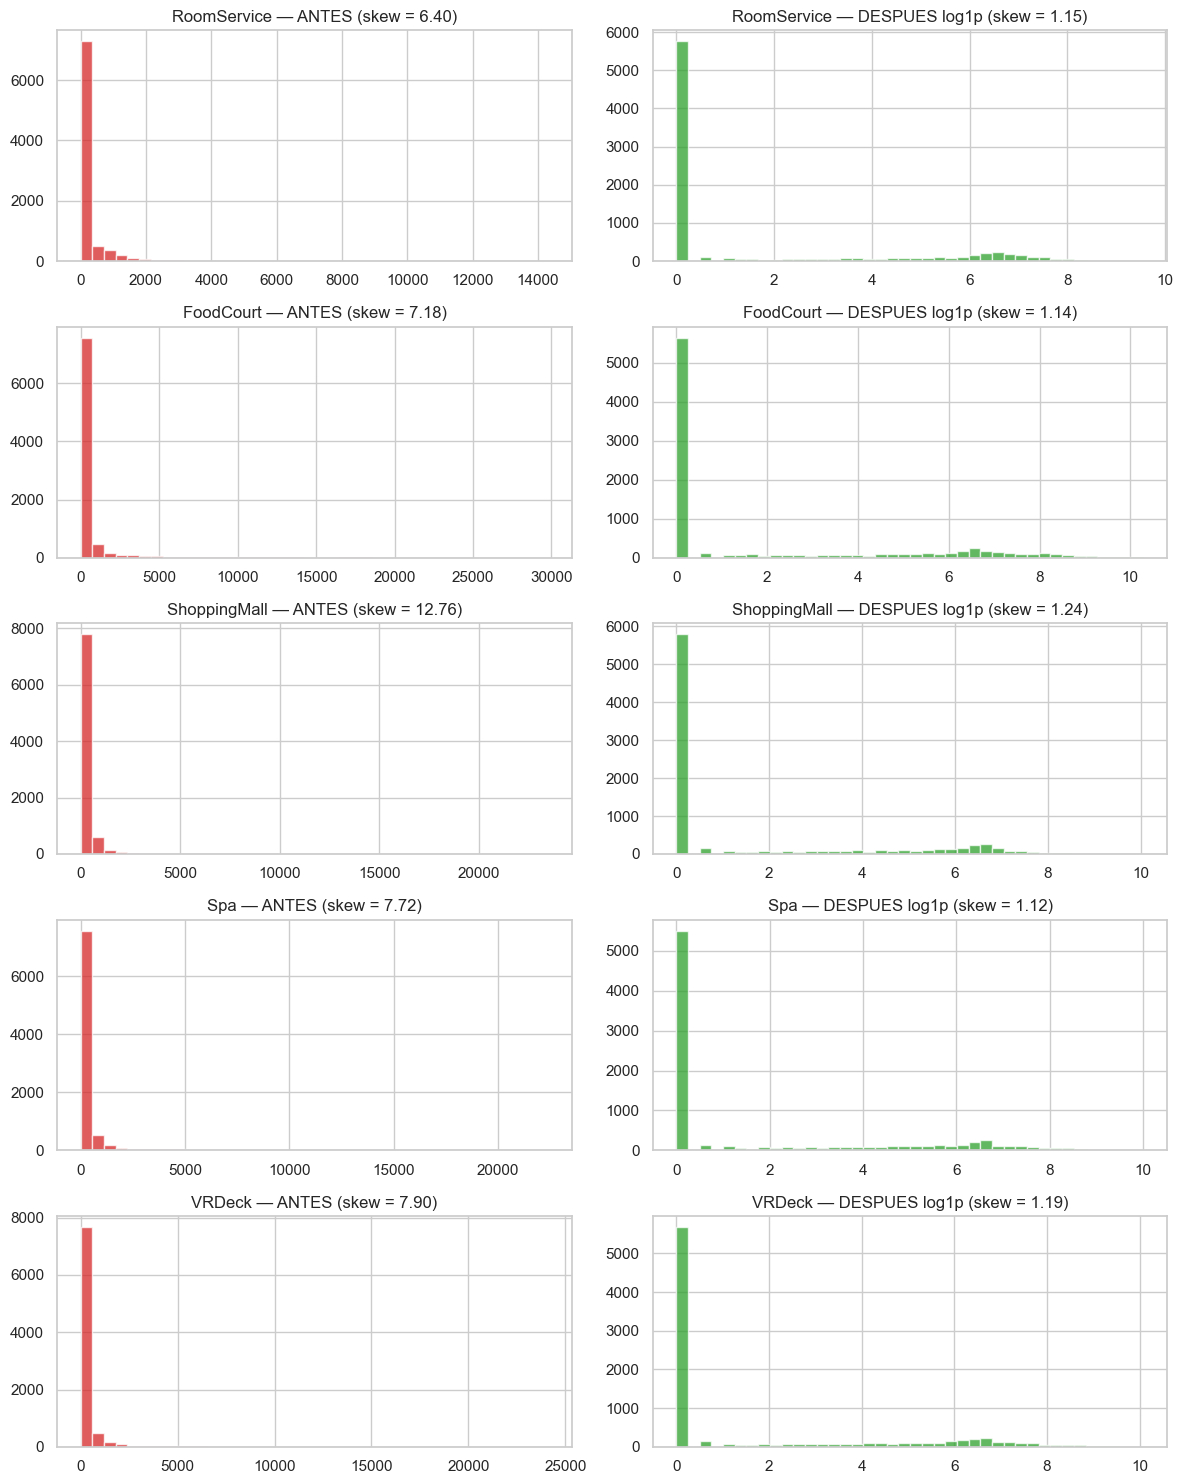

In [ ]:
fig, axes = plt.subplots(len(A_TRANSFORMAR), 2, figsize=(12, 3 * len(A_TRANSFORMAR)))

for fila, col in enumerate(A_TRANSFORMAR):
    train_e[col].hist(bins=40, ax=axes[fila, 0], color="tab:red", alpha=0.75)
    axes[fila, 0].set_title(f"{col} — ANTES (skew = {skew_antes[col]:.2f})")

    train_t[col].hist(bins=40, ax=axes[fila, 1], color="tab:green", alpha=0.75)
    axes[fila, 1].set_title(f"{col} — DESPUES log1p (skew = {train_t[col].skew():.2f})")

plt.tight_layout()
plt.show()

#### Interpretación — transformación de variables numéricas

**Qué se transformó y qué no.** Con el criterio `|skew| > 1`:

- **Se transforman los 5 rubros de gasto** (`RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`), con sesgos de 6.4 a 12.8. Son distribuciones donde la inmensa mayoría vale 0 y unos pocos pasajeros gastan decenas de miles.
- **`Age` (skew 0.43) y `Num` (skew 0.75) se dejan intactas.** Ambas están por debajo del umbral: `Age` es casi simétrica y `Num` tiene una asimetría leve. Transformarlas solo distorsionaría variables que ya están bien condicionadas.

**Por qué `log1p` y no `log`.** Aproximadamente el **63%** de los registros de gasto valen exactamente 0, y `log(0) = -inf`. `log1p` calcula `log(1 + x)`, está definida en 0 y devuelve 0, preservando esas filas sin introducir infinitos ni tener que sumar una constante arbitraria.

**Efecto medido.** El sesgo cae entre 82% y 90%:

| Variable | Antes | Después | Reducción |
|---|---|---|---|
| RoomService | 6.40 | 1.15 | 82.0% |
| FoodCourt | 7.18 | 1.14 | 84.1% |
| ShoppingMall | 12.76 | 1.24 | 90.3% |
| Spa | 7.72 | 1.12 | 85.5% |
| VRDeck | 7.90 | 1.19 | 84.9% |

**Por qué el sesgo residual no baja de ~1.1.** Los histogramas lo explican: `log1p` comprime la cola larga (el eje pasa de 0–30,000 a 0–10) y hace visible la distribución real de quienes sí gastaron, pero **no puede eliminar la barra en cero**, que concentra el 63% de los datos. Ese sesgo remanente no es una cola pesada sino *exceso de ceros* (zero-inflation), y ninguna transformación monótona lo corrige. Si se quisiera modelar explícitamente, la vía sería añadir una indicadora binaria del tipo `HaGastado`, no otra transformación.

**Sin fuga de información.** A diferencia de la imputación y el escalado, `log1p` es una función fija que no estima ningún parámetro a partir de los datos. Aplicarla a train y test por separado es seguro por construcción.

## 7. Escalado

Las variables numéricas quedaron en escalas muy distintas: `Num` llega a 1894, `Age` a 79 y los gastos transformados a ~10. Los modelos basados en distancia (KNN, SVM) y los que usan regularización (regresión logística) quedarían dominados por la variable de mayor rango, así que hace falta escalar.

Se escalan **únicamente las 7 columnas numéricas**. Las indicadoras 0/1 del one-hot y las binarias `CryoSleep`/`VIP` ya están en una escala comparable, y escalarlas destruiría su interpretación directa.

La elección del escalador se toma con evidencia, no por costumbre: primero se vuelve a medir la presencia de outliers **después** de la transformación de la sección 6, y luego se comparan los dos candidatos.

In [40]:
# ---- 7.1 Los outliers DESPUES de la transformacion --------------------------

filas = []
for col in NUM_COLS:
    q1, q3 = train_t[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    fuera = ((train_t[col] < q1 - 1.5 * iqr) | (train_t[col] > q3 + 1.5 * iqr)).mean() * 100
    filas.append({
        "columna": col, "Q1": q1, "mediana": train_t[col].median(), "Q3": q3,
        "IQR": iqr, "pct_outliers": round(fuera, 1),
        "min": train_t[col].min(), "max": train_t[col].max(),
    })

pd.DataFrame(filas).round(2)

,columna,Q1,mediana,Q3,IQR,pct_outliers,min,max
0,RoomService,0.0,0.0,3.74,3.74,0.0,0.0,9.57
1,FoodCourt,0.0,0.0,4.13,4.13,0.0,0.0,10.30
2,ShoppingMall,0.0,0.0,3.14,3.14,0.8,0.0,10.06
3,Spa,0.0,0.0,3.99,3.99,0.0,0.0,10.02
4,VRDeck,0.0,0.0,3.71,3.71,0.3,0.0,10.09
5,Age,20.0,27.0,37.00,17.00,1.9,0.0,79.00
6,Num,173.0,427.0,983.00,810.00,0.0,0.0,1894.00


In [ ]:
# ---- 7.2 Comparacion de los dos escaladores candidatos ----------------------
from sklearn.preprocessing import RobustScaler, StandardScaler

cero = pd.DataFrame([[0.0] * len(NUM_COLS)], columns=NUM_COLS)

comparacion_esc = {}
for nombre, Escalador in [("RobustScaler", RobustScaler), ("StandardScaler", StandardScaler)]:
    esc = Escalador().fit(train_t[NUM_COLS])
    comparacion_esc[nombre] = pd.Series(esc.transform(cero)[0], index=NUM_COLS)

pd.DataFrame(comparacion_esc).round(3)

,RobustScaler,StandardScaler
RoomService,0.000,-0.638
FoodCourt,0.000,-0.650
ShoppingMall,0.000,-0.623
Spa,0.000,-0.664
VRDeck,0.000,-0.640
Age,-1.588,-2.008
Num,-0.527,-1.177


In [42]:
# ---- 7.3 Aplicacion del RobustScaler ----------------------------------------
escalador = RobustScaler()
escalador.fit(train_t[NUM_COLS])


def escalar(df, escalador):
    """Escala unicamente las columnas numericas continuas.

    Las indicadoras 0/1 se dejan intactas: ya estan en escala comparable y
    escalarlas eliminaria su lectura directa como presencia/ausencia.
    """
    d = df.copy()
    d[NUM_COLS] = escalador.transform(d[NUM_COLS])
    return d


train_s = escalar(train_t, escalador)
test_s = escalar(test_t, escalador)

print("Parametros aprendidos de train:")
for col, centro, escala in zip(NUM_COLS, escalador.center_, escalador.scale_):
    print(f"  {col:<14} mediana={centro:>8.2f}   IQR={escala:>8.2f}")

Parametros aprendidos de train:
  RoomService    mediana=    0.00   IQR=    3.74
  FoodCourt      mediana=    0.00   IQR=    4.13
  ShoppingMall   mediana=    0.00   IQR=    3.14
  Spa            mediana=    0.00   IQR=    3.99
  VRDeck         mediana=    0.00   IQR=    3.71
  Age            mediana=   27.00   IQR=   17.00
  Num            mediana=  427.00   IQR=  810.00


In [43]:
# ---- 7.4 Verificacion del escalado ------------------------------------------
print("train_s:", train_s.shape, "| test_s:", test_s.shape)
print("nulos:", train_s.isna().sum().sum(), "/", test_s.isna().sum().sum())

print("\nRango de las numericas tras escalar (train):")
print(train_s[NUM_COLS].agg(["min", "median", "max"]).round(2).T)

# Las indicadoras deben seguir siendo estrictamente 0/1
indicadoras = [c for c in train_s.columns if c not in NUM_COLS + [TARGET]]
valores = set(np.unique(train_s[indicadoras].values))
print("\nValores presentes en las indicadoras:", valores)

train_s: (8693, 25) | test_s: (4277, 24)
nulos: 0 / 0

Rango de las numericas tras escalar (train):
               min  median   max
RoomService   0.00     0.0  2.56
FoodCourt     0.00     0.0  2.50
ShoppingMall  0.00     0.0  3.21
Spa           0.00     0.0  2.51
VRDeck        0.00     0.0  2.72
Age          -1.59     0.0  3.06
Num          -0.53     0.0  1.81

Valores presentes en las indicadoras: {np.int64(0), np.int64(1)}


#### Interpretación — elección del escalador

**Por qué hay que escalar.** Las 7 numéricas quedaron en rangos incomparables: `Num` llega a 1894, `Age` a 79 y los gastos transformados a ~10. Sin escalar, cualquier modelo que use distancias o regularización trataría a `Num` como ~190 veces más importante que un gasto, solo por su unidad de medida.

**Qué se escala y qué no.** Solo las 7 columnas numéricas continuas. Las 15 indicadoras del one-hot y las binarias `CryoSleep`/`VIP` ya viven en [0, 1]: escalarlas no corrige ningún desbalance de escala y sí destruye su lectura directa como presencia/ausencia.

**Por qué `RobustScaler` y no `StandardScaler`.** La sección 2.2 detectó ~21% de outliers por regla de Tukey en las columnas de gasto, lo que apuntaría de inmediato a un escalador robusto. Pero esa medición era sobre los datos crudos, y la celda 7.1 muestra que **después de `log1p` los outliers caen a menos del 2%**. Con ese dato solo, `StandardScaler` sería defendible. La decisión se sostiene en dos argumentos que siguen vigentes:

1. **El punto cero tiene significado y hay que preservarlo.** En las columnas de gasto, el valor 0 no es un número más: significa "este pasajero no consumió nada", y describe al ~65% de los registros. Como la mediana de esas columnas es exactamente 0, `RobustScaler` (que resta la mediana) deja ese 0 en **0.0**. `StandardScaler` (que resta la media) lo manda a **−0.638**, un valor arbitrario que además queda por debajo del de un pasajero que sí gastó poco. La celda 7.2 lo muestra explícitamente:

   | Columna | RobustScaler | StandardScaler |
   |---|---|---|
   | RoomService | **0.000** | −0.638 |
   | FoodCourt | **0.000** | −0.650 |
   | Spa | **0.000** | −0.664 |

2. **Las distribuciones siguen sin ser normales.** Aunque la cola larga desapareció, persiste el exceso de ceros: en los 5 gastos `Q1 = mediana = 0`. La media y la desviación estándar que usa `StandardScaler` asumen una distribución aproximadamente simétrica y no describen bien una masa puntual de ese tamaño. La mediana y el IQR sí.

Adicionalmente, `Age` conserva 1.9% de outliers legítimos (pasajeros de hasta 79 años) que no se eliminaron por ser información válida, y el escalador robusto evita que compriman al resto de la distribución.

**Disciplina train/test.** `escalador.fit()` se ejecuta solo sobre `train_t`. Los parámetros aprendidos (`center_` = medianas, `scale_` = IQR) se aplican tal cual a test mediante `transform`, siguiendo el mismo principio de las secciones 4 y 5.

## 8. Verificación final

### 8.1 Tabla resumen de decisiones

### 8.2 Conclusión

---

## Nota de uso de IA

_(completar)_